   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 3.2 MB/s eta 0:00:00
Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.62MB/s]

Train size: 60000 | Test size: 10000


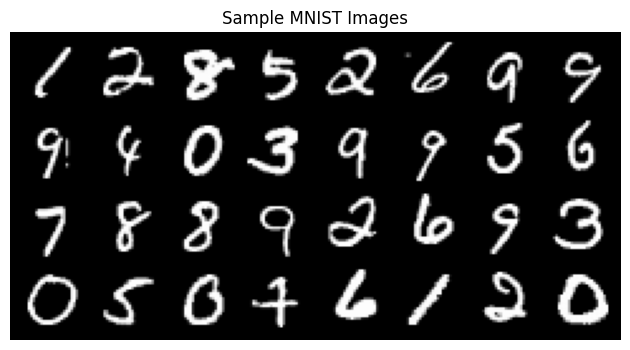

In [1]:
  # ============================================================
# TASK 8: Generative AI and Deep Learning Model Optimization
# Dataset: MNIST
# ============================================================

# Cell 1: Install dependencies
!pip install -q torch torchvision torch-pruning
!pip install -q matplotlib numpy pandas scikit-learn

# Cell 2: Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
torch.manual_seed(42)

# Cell 3: Data Loading (MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)

print("Train size:", len(train_dataset), "| Test size:", len(test_dataset))

# Visualize samples
sample_batch, _ = next(iter(train_loader))
plt.figure(figsize=(8,4))
plt.axis("off")
plt.title("Sample MNIST Images")
plt.imshow(np.transpose(vutils.make_grid(sample_batch[:32], padding=2, normalize=True), (1,2,0)))
plt.show()

PART A: Generative AI — DCGAN Implementation

Training DCGAN...
[Epoch 0/15] [Batch 0/469] LossD: 1.5631 LossG: 1.5057
[Epoch 0/15] [Batch 200/469] LossD: 0.6273 LossG: 3.0431
[Epoch 0/15] [Batch 400/469] LossD: 0.4837 LossG: 2.3206
[Epoch 1/15] [Batch 0/469] LossD: 0.9563 LossG: 3.2168
[Epoch 1/15] [Batch 200/469] LossD: 0.6096 LossG: 1.7974
[Epoch 1/15] [Batch 400/469] LossD: 0.4896 LossG: 1.6347
[Epoch 2/15] [Batch 0/469] LossD: 1.2586 LossG: 5.4677
[Epoch 2/15] [Batch 200/469] LossD: 0.2126 LossG: 2.2531
[Epoch 2/15] [Batch 400/469] LossD: 0.2980 LossG: 4.0541
[Epoch 3/15] [Batch 0/469] LossD: 0.5742 LossG: 3.3907
[Epoch 3/15] [Batch 200/469] LossD: 0.2038 LossG: 2.6993
[Epoch 3/15] [Batch 400/469] LossD: 0.2290 LossG: 3.0310
[Epoch 4/15] [Batch 0/469] LossD: 0.2543 LossG: 2.4672
[Epoch 4/15] [Batch 200/469] LossD: 0.1864 LossG: 3.1643
[Epoch 4/15] [Batch 400/469] LossD: 0.1165 LossG: 3.6859
[Epoch 5/15] [Batch 0/469] LossD: 0.2378 LossG: 3.2328
[Epoch 5/15] [Batch 200/469] LossD: 0.1861 LossG: 3.1825
[Epoch 5/15] [Batch 400/4

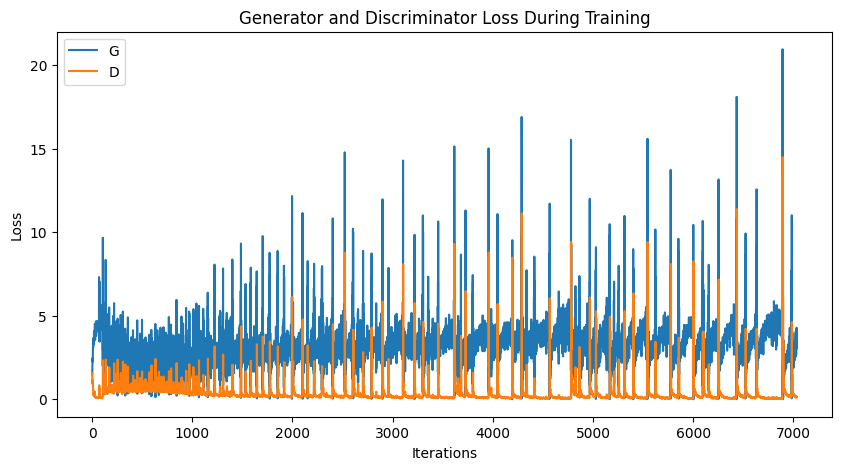

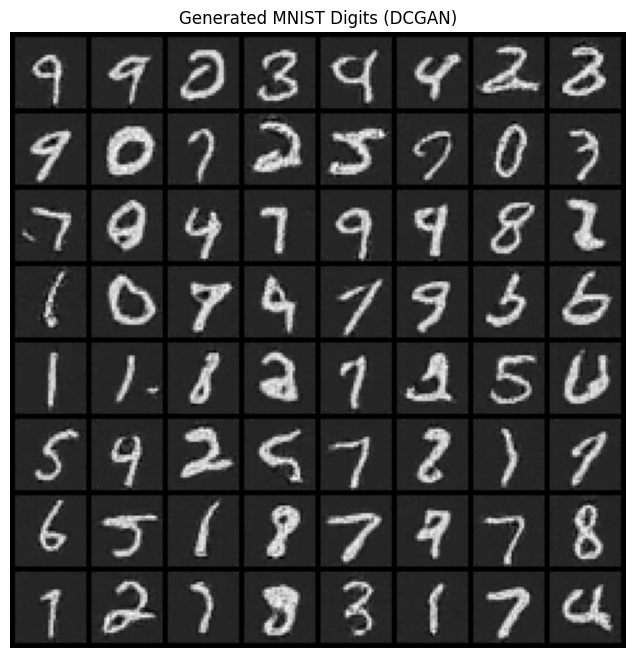

Generator saved.


In [2]:
# Cell 4: DCGAN - Generator
class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=1):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input: nz x 1 x 1
            nn.ConvTranspose2d(nz, ngf*4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),
            # 4x4
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),
            # 8x8
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # 16x16
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # 32x32 -> then upsample not needed; MNIST is 28x28
        )
    def forward(self, x):
        x = self.main(x)
        return F.interpolate(x, size=(28,28), mode='bilinear', align_corners=False)

# Cell 5: DCGAN - Discriminator
class Discriminator(nn.Module):
    def __init__(self, nc=1, ndf=64):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),
            # 7x7
            nn.Conv2d(ndf*2, ndf*4, 3, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),
            # 4x4
            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.main(x).view(-1, 1).squeeze(1)

# Cell 6: Setup DCGAN
nz, ngf, ndf, nc = 100, 64, 64, 1
G = Generator(nz, ngf, nc).to(device)
D = Discriminator(nc, ndf).to(device)

criterion = nn.BCELoss()
optimizerG = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizerD = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

fixed_noise = torch.randn(64, nz, 1, 1, device=device)
G_losses, D_losses, img_list = [], [], []

# Cell 7: DCGAN Training Loop
num_epochs = 15
print("Training DCGAN...")
for epoch in range(num_epochs):
    for i, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # ---- Train Discriminator ----
        D.zero_grad()
        real_labels = torch.ones(b_size, device=device)
        fake_labels = torch.zeros(b_size, device=device)

        out_real = D(real_imgs)
        lossD_real = criterion(out_real, real_labels)

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_imgs = G(noise)
        out_fake = D(fake_imgs.detach())
        lossD_fake = criterion(out_fake, fake_labels)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # ---- Train Generator ----
        G.zero_grad()
        out_fake = D(fake_imgs)
        lossG = criterion(out_fake, real_labels)
        lossG.backward()
        optimizerG.step()

        G_losses.append(lossG.item())
        D_losses.append(lossD.item())

        if i % 200 == 0:
            print(f"[Epoch {epoch}/{num_epochs}] [Batch {i}/{len(train_loader)}] "
                  f"LossD: {lossD.item():.4f} LossG: {lossG.item():.4f}")

    # save sample images each epoch
    with torch.no_grad():
        fake = G(fixed_noise).detach().cpu()
    img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

# Cell 8: Plot Losses + Generated Images
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Cell 9: Show final generated samples
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Generated MNIST Digits (DCGAN)")
plt.imshow(np.transpose(img_list[-1], (1,2,0)))
plt.show()

# Cell 10: Save generator weights (will use as teacher for distillation)
torch.save(G.state_dict(), "dcgan_generator.pth")
print("Generator saved.")

PART B: Model Optimization

In [3]:
# Cell 11: Baseline CNN Classifier (Teacher)
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(64*5*5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, loader, epochs=3, lr=1e-3, verbose=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()
    for ep in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
    return model

def evaluate(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

def model_size_mb(model):
    torch.save(model.state_dict(), "tmp.pth")
    size = os.path.getsize("tmp.pth") / 1e6
    os.remove("tmp.pth")
    return size

def inference_time(model, n_batches=20):
    model.eval()
    start = time.time()
    with torch.no_grad():
        for i, (x, _) in enumerate(test_loader):
            if i >= n_batches: break
            _ = model(x.to(device))
    return (time.time() - start) / n_batches

# Train teacher
teacher = SimpleCNN().to(device)
train_model(teacher, train_loader, epochs=3)
teacher_acc = evaluate(teacher)
teacher_size = model_size_mb(teacher)
teacher_time = inference_time(teacher)
print(f"Teacher: Acc={teacher_acc:.2f}%, Params={count_params(teacher)}, Size={teacher_size:.2f} MB")

Teacher: Acc=99.03%, Params=225034, Size=0.90 MB


B1: Pruning (using torch-pruning)

In [4]:
# Cell 12: Pruning
import torch_pruning as tp

def prune_model(model, prune_ratio=0.5):
    model = copy.deepcopy(model)
    example_input = torch.randn(1,1,28,28).to(device)
    imp = tp.importance.MagnitudeImportance(p=2)
    ignored_layers = [model.fc2]

    pruner = tp.pruner.MagnitudePruner(
        model, example_input,
        importance=imp,
        pruning_ratio=prune_ratio,
        ignored_layers=ignored_layers,
    )
    pruner.step()
    return model

pruned_model = prune_model(teacher, prune_ratio=0.5).to(device)
# Fine-tune
train_model(pruned_model, train_loader, epochs=2)
pruned_acc = evaluate(pruned_model)
pruned_size = model_size_mb(pruned_model)
pruned_time = inference_time(pruned_model)
print(f"Pruned: Acc={pruned_acc:.2f}%, Params={count_params(pruned_model)}, Size={pruned_size:.2f} MB")

Pruned: Acc=99.02%, Params=56714, Size=0.23 MB


B2: Quantization (Dynamic INT8)

In [5]:
# Cell 13: Quantization
def quantize_model(model):
    model_cpu = copy.deepcopy(model).cpu().eval()
    quantized = torch.quantization.quantize_dynamic(
        model_cpu, {nn.Linear, nn.Conv2d}, dtype=torch.qint8
    )
    return quantized

quant_model = quantize_model(teacher)

# Evaluate quantized model (must run on CPU)
def evaluate_cpu(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

quant_acc = evaluate_cpu(quant_model)
# Size approximation
torch.save(quant_model.state_dict(), "quant.pth")
quant_size = os.path.getsize("quant.pth") / 1e6
os.remove("quant.pth")
print(f"Quantized: Acc={quant_acc:.2f}%, Size={quant_size:.2f} MB")

/tmp/ipykernel_866/2615968418.py:4: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized = torch.quantization.quantize_dynamic(


Quantized: Acc=99.02%, Size=0.29 MB


B3: Knowledge Distillation

In [6]:
# Cell 14: Knowledge Distillation
class StudentCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, 1)
        self.conv2 = nn.Conv2d(16, 32, 3, 1)
        self.fc1 = nn.Linear(32*5*5, 64)
        self.fc2 = nn.Linear(64, 10)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def distillation_loss(student_logits, teacher_logits, targets, T=4.0, alpha=0.7):
    soft = F.kl_div(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1),
        reduction='batchmean'
    ) * (T * T)
    hard = F.cross_entropy(student_logits, targets)
    return alpha * soft + (1 - alpha) * hard

def train_distill(student, teacher, loader, epochs=5, T=4.0, alpha=0.7, lr=1e-3):
    optimizer = optim.Adam(student.parameters(), lr=lr)
    teacher.eval()
    student.train()
    for ep in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with torch.no_grad():
                t_logits = teacher(x)
            s_logits = student(x)
            loss = distillation_loss(s_logits, t_logits, y, T, alpha)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
    return student

student = StudentCNN().to(device)
student = train_distill(student, teacher, train_loader, epochs=5)

student_acc = evaluate(student)
student_size = model_size_mb(student)
student_time = inference_time(student)
print(f"Student (Distilled): Acc={student_acc:.2f}%, Params={count_params(student)}, Size={student_size:.2f} MB")

# Also train student from scratch for comparison
student_scratch = StudentCNN().to(device)
train_model(student_scratch, train_loader, epochs=5)
scratch_acc = evaluate(student_scratch)
print(f"Student (Scratch):   Acc={scratch_acc:.2f}%")

Student (Distilled): Acc=98.89%, Params=56714, Size=0.23 MB
Student (Scratch):   Acc=98.77%


B4: Comparison Table

In [7]:
# Cell 15: Final Comparison
import pandas as pd

results = pd.DataFrame([
    {"Model": "Teacher CNN (Baseline)",
     "Accuracy (%)": round(teacher_acc, 2),
     "Params": count_params(teacher),
     "Size (MB)": round(teacher_size, 3),
     "Inference (s/batch)": round(teacher_time, 4)},
    {"Model": "Pruned CNN (50%)",
     "Accuracy (%)": round(pruned_acc, 2),
     "Params": count_params(pruned_model),
     "Size (MB)": round(pruned_size, 3),
     "Inference (s/batch)": round(pruned_time, 4)},
    {"Model": "Quantized INT8",
     "Accuracy (%)": round(quant_acc, 2),
     "Params": "~same",
     "Size (MB)": round(quant_size, 3),
     "Inference (s/batch)": "-"},
    {"Model": "Student (Distilled)",
     "Accuracy (%)": round(student_acc, 2),
     "Params": count_params(student),
     "Size (MB)": round(student_size, 3),
     "Inference (s/batch)": round(student_time, 4)},
    {"Model": "Student (From Scratch)",
     "Accuracy (%)": round(scratch_acc, 2),
     "Params": count_params(student_scratch),
     "Size (MB)": round(model_size_mb(student_scratch), 3),
     "Inference (s/batch)": "-"},
])

print("\n========= PERFORMANCE COMPARISON =========\n")
print(results.to_string(index=False))


========= PERFORMANCE COMPARISON =========

                 Model  Accuracy (%) Params  Size (MB) Inference (s/batch)
Teacher CNN (Baseline)         99.03 225034      0.903              0.0735
      Pruned CNN (50%)         99.02  56714      0.230               0.055
        Quantized INT8         99.02  ~same      0.286                   -
   Student (Distilled)         98.89  56714      0.230              0.0806
Student (From Scratch)         98.77  56714      0.230                   -
